<a href="https://colab.research.google.com/github/abhishekch800-hiy/AI-ML-Project-on-WEATHER-BASED-CROP-RECOMMENDATION-USING-MACHINE-LEARNING-/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))

Saving crop_data_10000.csv to crop_data_10000.csv
User uploaded file "crop_data_10000.csv" with length 320160 bytes


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------
# 📁 Load dataset
# -------------------------------
df = pd.read_csv("crop_data_10000.csv")

# ⚠️ Ensure rainfall column exists
# If not, simulate (temporary)
if 'rainfall' not in df.columns:
    import numpy as np
    df['rainfall'] = np.random.uniform(200, 2000, len(df))

# -------------------------------
# 🔤 Encoding
# -------------------------------
le_season = LabelEncoder()
le_crop = LabelEncoder()

df['season'] = le_season.fit_transform(df['season'])
df['crop'] = le_crop.fit_transform(df['crop'])

# -------------------------------
# 🎯 Features & Target
# -------------------------------
X = df[['temperature', 'humidity', 'rainfall', 'region', 'season']]
y = df['crop']

# -------------------------------
# ✂️ Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 🌲 Improved Model
# -------------------------------
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------------
# 🌍 Region Info
# -------------------------------
region_info = {
    1: ("Western Himalayan Region", "J&K, HP, Uttarakhand"),
    2: ("Eastern Himalayan Region", "NE States, WB"),
    3: ("Lower Gangetic Plains", "WB, Bihar"),
    4: ("Middle Gangetic Plains", "Eastern UP, Bihar"),
    5: ("Upper Gangetic Plains", "Western UP"),
    6: ("Trans-Gangetic Plains", "Punjab, Haryana"),
    7: ("Eastern Plateau & Hills", "Odisha, Jharkhand"),
    8: ("Central Plateau & Hills", "MP, Rajasthan"),
    9: ("Western Plateau & Hills", "MP, Maharashtra"),
    10: ("Southern Plateau & Hills", "AP, Karnataka, TN"),
    11: ("East Coast Plains", "Odisha, AP"),
    12: ("West Coast Plains", "Kerala, Karnataka"),
    13: ("Gujarat Plains", "Gujarat"),
    14: ("Western Dry Region", "Rajasthan"),
    15: ("Island Region", "A&N Islands")
}

# -------------------------------
# 📋 POP
# -------------------------------
pop_dict = {
    "rice": ["Nursery raising", "Maintain water level"],
    "wheat": ["Timely sowing", "CRI irrigation"],
    "maize": ["Hybrid seeds", "Spacing"],
    "cotton": ["Bt cotton", "Pest control"],
    "groundnut": ["Gypsum use", "Drainage"],
    "millet": ["Drought tolerant"],
    "barley": ["Low irrigation"],
    "coconut": ["Organic manure"],
    "pulses": ["Low nitrogen"],
    "spices": ["Organic practices"],
    "tea": ["Pruning required"],
    "fruits": ["Horticulture practices"]
}

# -------------------------------
# 🌱 NPK
# -------------------------------
npk_dict = {
    "rice": "High N (~4:2:1)",
    "wheat": "Balanced NPK",
    "maize": "High N",
    "pulses": "Low N, high P",
    "cotton": "High N & K",
    "groundnut": "High P & K",
    "millet": "Low fertilizer",
    "barley": "Moderate NPK",
    "coconut": "High K",
    "spices": "Balanced",
    "tea": "High N",
    "fruits": "Balanced"
}

# -------------------------------
# 🔮 Prediction (TOP-3)
# -------------------------------
def predict_crop(temp, humidity, rainfall, region, season):
    try:
        season_encoded = le_season.transform([season])[0]

        probs = model.predict_proba([[temp, humidity, rainfall, region, season_encoded]])[0]
        top3_idx = probs.argsort()[-3:][::-1]

        crops = le_crop.inverse_transform(top3_idx)
        region_name, states = region_info.get(region)

        return crops, region_name, states

    except:
        return "Invalid input!"

# -------------------------------
# 🧷 Input
# -------------------------------
print("\n🌾 SMART CROP SYSTEM (ADVANCED) 🌾")

temp = float(input("Temperature: "))
humidity = float(input("Humidity: "))
rainfall = float(input("Rainfall (mm): "))
region = int(input("Region (1–15): "))
season = input("Season: ").lower()

# -------------------------------
# ✅ Output
# -------------------------------
result = predict_crop(temp, humidity, rainfall, region, season)

if isinstance(result, tuple):
    crops, region_name, states = result

    print("\n🌍 Region:", region_name)
    print("📍 States:", states)

    print("\n🌾 Top 3 Recommended Crops:")
    for i, crop in enumerate(crops, 1):
        print(f"\n{i}. {crop}")

        print("📋 POP:")
        for p in pop_dict.get(crop, []):
            print("•", p)

        print("🌱 NPK:", npk_dict.get(crop, ""))

else:
    print(result)


🌾 SMART CROP SYSTEM (ADVANCED) 🌾
Temperature: 50
Humidity: 80
Rainfall (mm): 600
Region (1–15): 7
Season: Summer

🌍 Region: Eastern Plateau & Hills
📍 States: Odisha, Jharkhand

🌾 Top 3 Recommended Crops:

1. maize
📋 POP:
• Hybrid seeds
• Spacing
🌱 NPK: High N

2. pulses
📋 POP:
• Low nitrogen
🌱 NPK: Low N, high P

3. rice
📋 POP:
• Nursery raising
• Maintain water level
🌱 NPK: High N (~4:2:1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# -------------------------------
# 📊 Silhouette Score (Clustering)
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

sil_score = silhouette_score(X, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5555189520383961


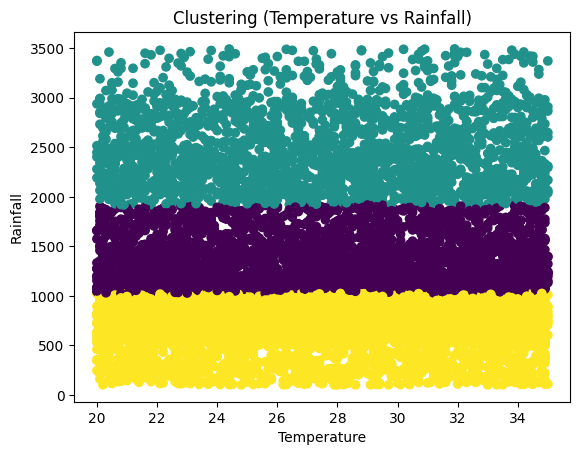

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

plt.figure()
plt.scatter(X['temperature'], X['rainfall'], c=labels)
plt.title("Clustering (Temperature vs Rainfall)")
plt.xlabel("Temperature")
plt.ylabel("Rainfall")
plt.show()

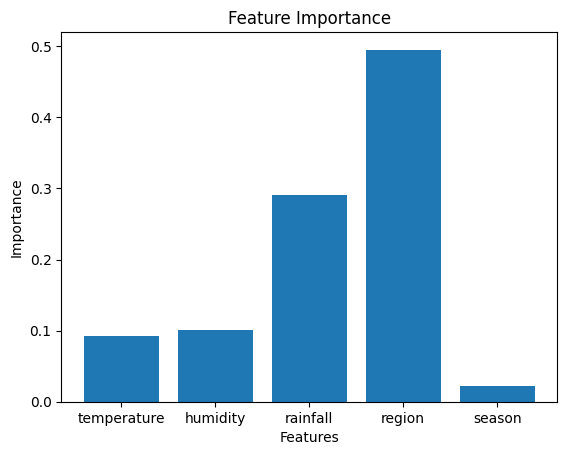

In [ ]:
plt.figure()
plt.bar(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

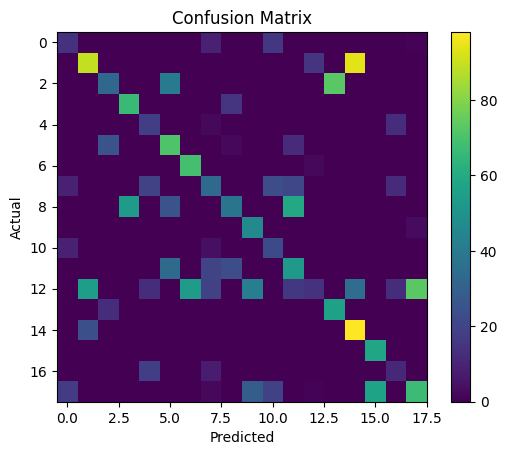

In [ ]:
from sklearn.metrics import confusion_matrix

# Define y_pred before using it
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

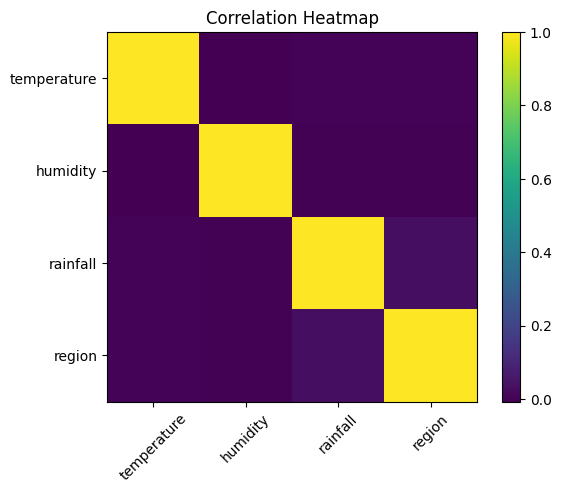

In [ ]:
# Correlation Matrix
corr = df[['temperature','humidity','rainfall','region']].corr()

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()

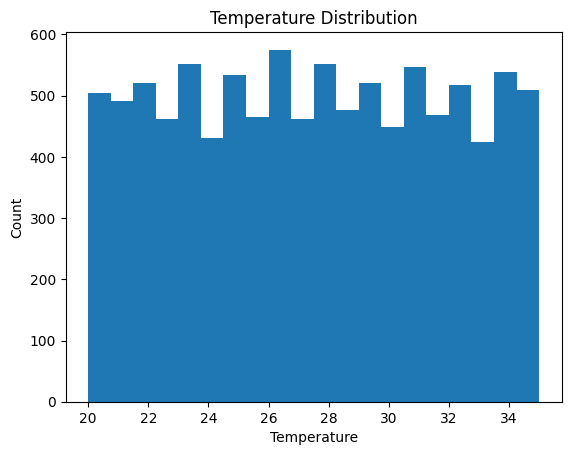

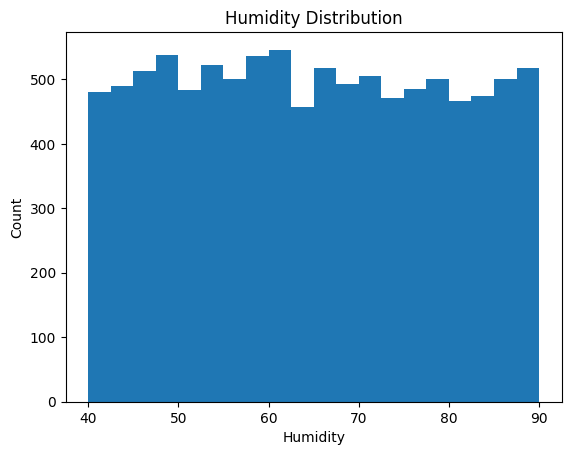

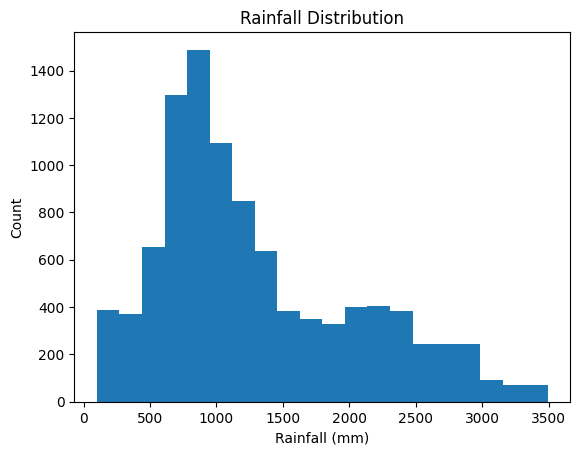

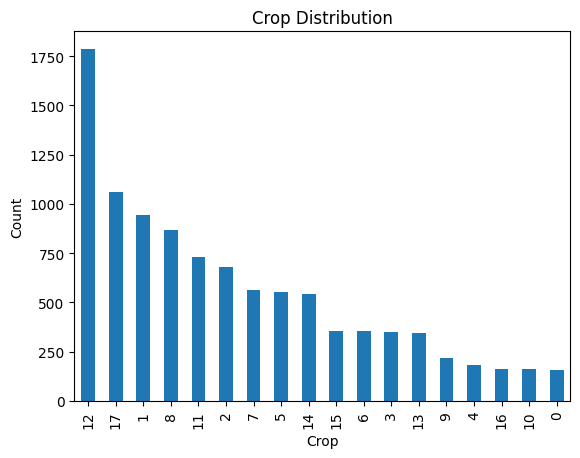

In [ ]:
import matplotlib.pyplot as plt

# Temperature Distribution
plt.figure()
plt.hist(df['temperature'], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.show()

# Humidity Distribution
plt.figure()
plt.hist(df['humidity'], bins=20)
plt.title("Humidity Distribution")
plt.xlabel("Humidity")
plt.ylabel("Count")
plt.show()

# Rainfall Distribution
plt.figure()
plt.hist(df['rainfall'], bins=20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Count")
plt.show()

# Crop Distribution
plt.figure()
df['crop'].value_counts().plot(kind='bar')
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

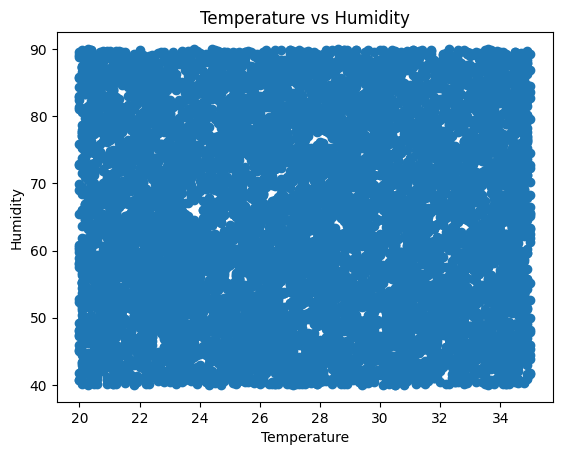

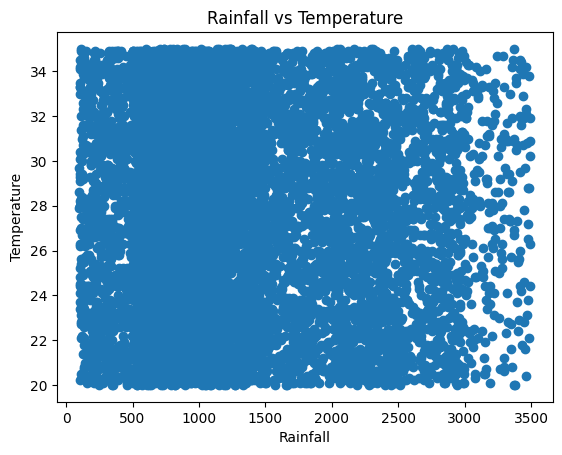

In [ ]:
# Temperature vs Humidity
plt.figure()
plt.scatter(df['temperature'], df['humidity'])
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

# Rainfall vs Temperature
plt.figure()
plt.scatter(df['rainfall'], df['temperature'])
plt.title("Rainfall vs Temperature")
plt.xlabel("Rainfall")
plt.ylabel("Temperature")
plt.show()

In [ ]:
# -------------------------------
# 📊 EVALUATION METRICS
# -------------------------------
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Accuracy: 0.429
F1 Score: 0.38054393097708883
Confusion Matrix:
 [[14  0  0  0  0  0  0  9  0  0 16  0  0  0  0  0  0  1]
 [ 0 89  0  0  0  0  0  0  0  0  0  0 15  0 94  0  0  0]
 [ 0  0 33  0  0 40  0  0  0  0  0  0  0 73  0  0  0  0]
 [ 0  0  0 66  0  0  0  0 15  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 18  0  0  2  0  0  0  0  0  0  0  0 13  0]
 [ 0  0 25  0  0 71  0  0  2  0  0 12  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 69  0  0  0  0  0  2  0  0  0  0  0]
 [ 9  0  0  0 19  0  0 34  0  0 23 21  0  0  0  0 12  0]
 [ 0  0  0 54  0 25  0  0 38  0  0 59  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 47  0  0  0  0  0  0  0  3]
 [ 9  0  0  0  0  0  0  4  0  0 22  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 34  0 20 23  0  0 53  0  0  0  0  0  0]
 [ 0 55  0  0 13  0 54 19  0 42  0 16 14  0 35  0 13 73]
 [ 0  0 13  0  0  0  0  0  0  0  0  0  0 56  0  0  0  0]
 [ 0 24  0  0  0  0  0  0  0  0  0  0  0  0 98  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 58  0  0]
 [ 0  0  0  0 18  0  0

# Task
Import `KMeans` from `sklearn.cluster` to cell `mSE_O0Q1i57D`, then execute the cell to calculate and print the Silhouette Score.

## Import KMeans

### Subtask:
Add `from sklearn.cluster import KMeans` to the top of cell `mSE_O0Q1i57D` to make the `KMeans` class available.
